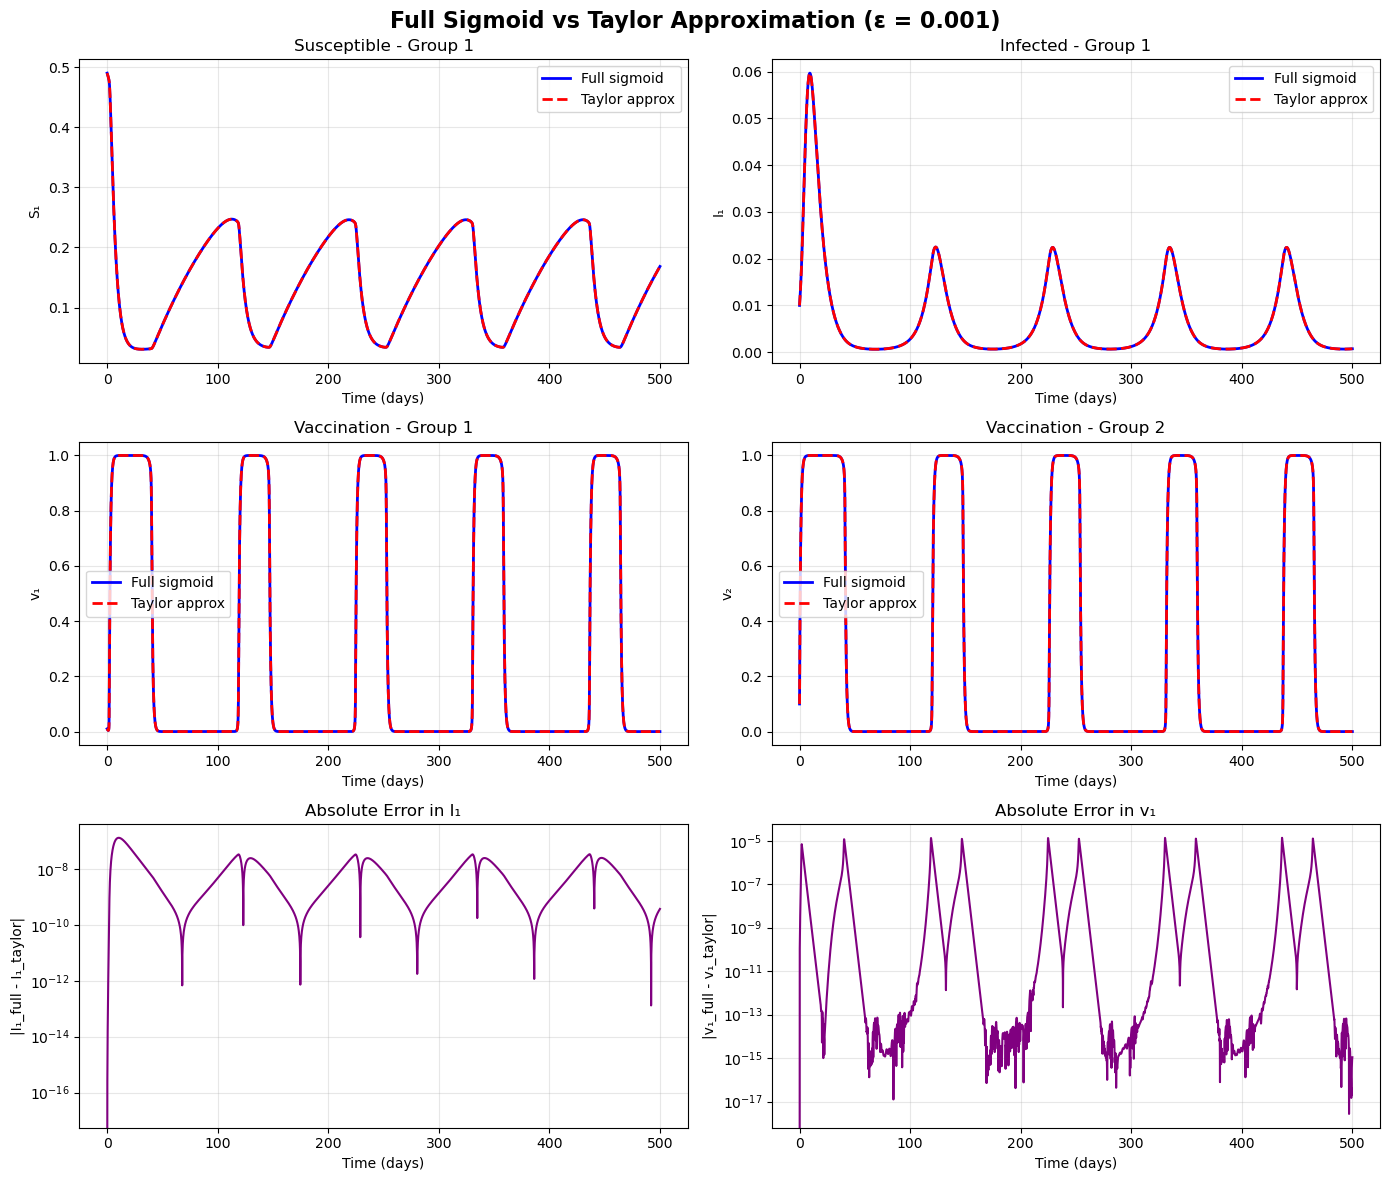

COMPARISON: FULL SIGMOID vs TAYLOR APPROXIMATION (ε = 0.001)

Maximum absolute errors:
  max|S₁_full - S₁_taylor| = 4.99e-07
  max|I₁_full - I₁_taylor| = 1.28e-07
  max|v₁_full - v₁_taylor| = 1.36e-05
  max|S₂_full - S₂_taylor| = 4.68e-06
  max|I₂_full - I₂_taylor| = 2.94e-07
  max|v₂_full - v₂_taylor| = 1.31e-04

Mean absolute errors:
  mean|S₁_full - S₁_taylor| = 7.40e-08
  mean|I₁_full - I₁_taylor| = 1.07e-08
  mean|v₁_full - v₁_taylor| = 3.55e-07

INTERPRETATION

If errors are small (e.g., < 1e-3), the Taylor approximation is valid,
and our H(φ) analysis based on linearized G is trustworthy.

If errors are large, we may need smaller ε or the coupling is too strong
for the weak coupling theory to apply.


ERROR SCALING WITH ε
(Taylor error should scale as ε² since we kept linear term)

ε = 0.0001   → max|I₁ error| = 1.29e-09, max|v₁ error| = 1.24e-07
ε = 0.001    → max|I₁ error| = 1.28e-07, max|v₁ error| = 1.36e-05
ε = 0.01     → max|I₁ error| = 1.22e-05, max|v₁ error| = 1.36e-03
ε 

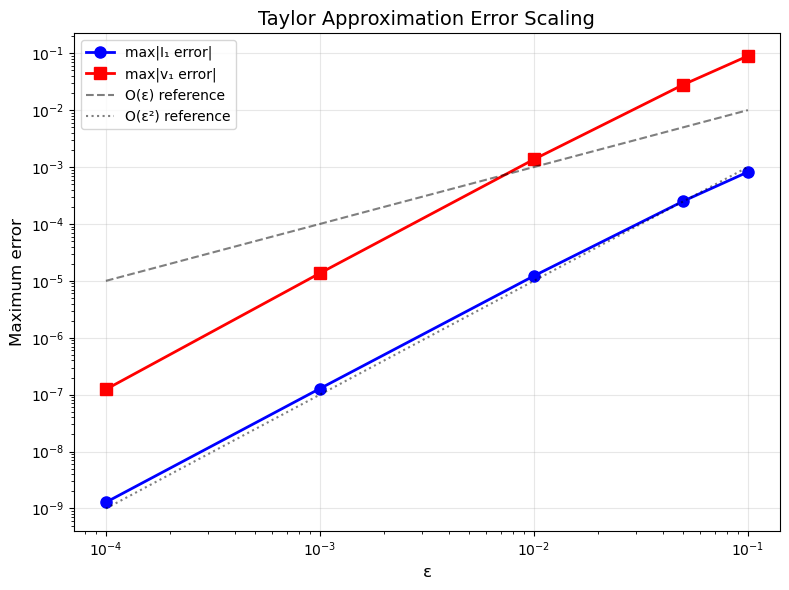

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =============================================================================
# COMPARE: FULL SIGMOID vs TAYLOR APPROXIMATION
# =============================================================================

# -----------------------------------------------------------------------------
# System 1: FULL coupled system (real sigmoid)
# -----------------------------------------------------------------------------
def coupled_sirv_full(t, y, alpha, beta, gamma, epsilon, eta, theta, kappa, rho, psi):
    """
    Coupled SIRv system with FULL sigmoid (no approximation)
    """
    S1, I1, v1, S2, I2, v2 = y
    
    # Group 1 dynamics
    dS1 = alpha*(psi - S1 - I1) - beta*S1*(I1/psi) - eta*v1*S1
    dI1 = -gamma*I1 + beta*S1*(I1/psi)
    # Full sigmoid with coupling inside
    xi_c1 = kappa * (beta*I1/psi - rho - theta*(1 - 2*((1-epsilon)*v1 + epsilon*v2)))
    dv1 = -v1 + 1/(1 + np.exp(-xi_c1))
    
    # Group 2 dynamics
    dS2 = alpha*(1 - psi - S2 - I2) - beta*S2*(I2/(1-psi)) - eta*v2*S2
    dI2 = -gamma*I2 + beta*S2*(I2/(1-psi))
    # Full sigmoid with coupling inside
    xi_c2 = kappa * (beta*I2/(1-psi) - rho - theta*(1 - 2*((1-epsilon)*v2 + epsilon*v1)))
    dv2 = -v2 + 1/(1 + np.exp(-xi_c2))
    
    return [dS1, dI1, dv1, dS2, dI2, dv2]


# -----------------------------------------------------------------------------
# System 2: TAYLOR APPROXIMATED system (linear term only)
# -----------------------------------------------------------------------------
def coupled_sirv_taylor(t, y, alpha, beta, gamma, epsilon, eta, theta, kappa, rho, psi):
    """
    Coupled SIRv system with TAYLOR APPROXIMATED sigmoid
    
    σ(ξ_c) ≈ σ(ξ_0) + σ'(ξ_0) · (ξ_c - ξ_0)
    
    where:
    - ξ_0 = κ(βI/ψ - ρ - θ(1-2v))  [uncoupled]
    - ξ_c - ξ_0 = -2εκθ(v_self - v_other) = 2εκθ(v_other - v_self)
    - σ'(ξ) = σ(ξ)(1 - σ(ξ))
    """
    S1, I1, v1, S2, I2, v2 = y
    
    # Group 1 dynamics
    dS1 = alpha*(psi - S1 - I1) - beta*S1*(I1/psi) - eta*v1*S1
    dI1 = -gamma*I1 + beta*S1*(I1/psi)
    
    # Taylor approximation for v1
    xi_0_1 = kappa * (beta*I1/psi - rho - theta*(1 - 2*v1))  # uncoupled argument
    sigma_0_1 = 1 / (1 + np.exp(-xi_0_1))  # σ(ξ_0)
    sigma_prime_1 = sigma_0_1 * (1 - sigma_0_1)  # σ'(ξ_0)
    zeta_1 = 2 * kappa * theta * (v2 - v1)  # ξ_c - ξ_0 = ε * ζ, so ζ = 2κθ(v2-v1)
    
    dv1 = -v1 + sigma_0_1 + epsilon * sigma_prime_1 * zeta_1
    
    # Group 2 dynamics
    dS2 = alpha*(1 - psi - S2 - I2) - beta*S2*(I2/(1-psi)) - eta*v2*S2
    dI2 = -gamma*I2 + beta*S2*(I2/(1-psi))
    
    # Taylor approximation for v2
    xi_0_2 = kappa * (beta*I2/(1-psi) - rho - theta*(1 - 2*v2))  # uncoupled argument
    sigma_0_2 = 1 / (1 + np.exp(-xi_0_2))  # σ(ξ_0)
    sigma_prime_2 = sigma_0_2 * (1 - sigma_0_2)  # σ'(ξ_0)
    zeta_2 = 2 * kappa * theta * (v1 - v2)  # ξ_c - ξ_0 = ε * ζ, so ζ = 2κθ(v1-v2)
    
    dv2 = -v2 + sigma_0_2 + epsilon * sigma_prime_2 * zeta_2
    
    return [dS1, dI1, dv1, dS2, dI2, dv2]


# -----------------------------------------------------------------------------
# Parameters
# -----------------------------------------------------------------------------
params = {
    'alpha': 0.01,
    'beta': 0.5,
    'gamma': 1/7,
    'epsilon': 0.001,  # Small epsilon for Taylor approximation to be valid
    'eta': 1/7,
    'theta': 0.01,
    'kappa': 1000,
    'rho': 0.01,
    'psi': 0.5
}

# Initial conditions
y0 = [0.49, 0.01, 0.01, 0.4, 0.1, 0.1]

# Time span
t_span = (0, 500)
t_eval = np.linspace(t_span[0], t_span[1], 5000)

# -----------------------------------------------------------------------------
# Solve both systems
# -----------------------------------------------------------------------------
sol_full = solve_ivp(
    coupled_sirv_full,
    t_span,
    y0,
    args=(params['alpha'], params['beta'], params['gamma'], params['epsilon'],
          params['eta'], params['theta'], params['kappa'], params['rho'], params['psi']),
    t_eval=t_eval,
    method='LSODA',
    rtol=1e-10,
    atol=1e-12
)

sol_taylor = solve_ivp(
    coupled_sirv_taylor,
    t_span,
    y0,
    args=(params['alpha'], params['beta'], params['gamma'], params['epsilon'],
          params['eta'], params['theta'], params['kappa'], params['rho'], params['psi']),
    t_eval=t_eval,
    method='LSODA',
    rtol=1e-10,
    atol=1e-12
)

# Extract solutions
S1_full, I1_full, v1_full, S2_full, I2_full, v2_full = sol_full.y
S1_taylor, I1_taylor, v1_taylor, S2_taylor, I2_taylor, v2_taylor = sol_taylor.y

# -----------------------------------------------------------------------------
# Plot comparison
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle(f'Full Sigmoid vs Taylor Approximation (ε = {params["epsilon"]})', 
             fontsize=16, fontweight='bold')

# S1 comparison
ax = axes[0, 0]
ax.plot(sol_full.t, S1_full, 'b-', linewidth=2, label='Full sigmoid')
ax.plot(sol_taylor.t, S1_taylor, 'r--', linewidth=2, label='Taylor approx')
ax.set_xlabel('Time (days)')
ax.set_ylabel('S₁')
ax.set_title('Susceptible - Group 1')
ax.legend()
ax.grid(True, alpha=0.3)

# I1 comparison
ax = axes[0, 1]
ax.plot(sol_full.t, I1_full, 'b-', linewidth=2, label='Full sigmoid')
ax.plot(sol_taylor.t, I1_taylor, 'r--', linewidth=2, label='Taylor approx')
ax.set_xlabel('Time (days)')
ax.set_ylabel('I₁')
ax.set_title('Infected - Group 1')
ax.legend()
ax.grid(True, alpha=0.3)

# v1 comparison
ax = axes[1, 0]
ax.plot(sol_full.t, v1_full, 'b-', linewidth=2, label='Full sigmoid')
ax.plot(sol_taylor.t, v1_taylor, 'r--', linewidth=2, label='Taylor approx')
ax.set_xlabel('Time (days)')
ax.set_ylabel('v₁')
ax.set_title('Vaccination - Group 1')
ax.legend()
ax.grid(True, alpha=0.3)

# v2 comparison
ax = axes[1, 1]
ax.plot(sol_full.t, v2_full, 'b-', linewidth=2, label='Full sigmoid')
ax.plot(sol_taylor.t, v2_taylor, 'r--', linewidth=2, label='Taylor approx')
ax.set_xlabel('Time (days)')
ax.set_ylabel('v₂')
ax.set_title('Vaccination - Group 2')
ax.legend()
ax.grid(True, alpha=0.3)

# Difference in I1
ax = axes[2, 0]
ax.plot(sol_full.t, np.abs(I1_full - I1_taylor), 'purple', linewidth=1.5)
ax.set_xlabel('Time (days)')
ax.set_ylabel('|I₁_full - I₁_taylor|')
ax.set_title('Absolute Error in I₁')
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Difference in v1
ax = axes[2, 1]
ax.plot(sol_full.t, np.abs(v1_full - v1_taylor), 'purple', linewidth=1.5)
ax.set_xlabel('Time (days)')
ax.set_ylabel('|v₁_full - v₁_taylor|')
ax.set_title('Absolute Error in v₁')
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('sigmoid_comparison.png', dpi=150)
plt.show()

# -----------------------------------------------------------------------------
# Print error statistics
# -----------------------------------------------------------------------------
print("="*70)
print(f"COMPARISON: FULL SIGMOID vs TAYLOR APPROXIMATION (ε = {params['epsilon']})")
print("="*70)

print("\nMaximum absolute errors:")
print(f"  max|S₁_full - S₁_taylor| = {np.max(np.abs(S1_full - S1_taylor)):.2e}")
print(f"  max|I₁_full - I₁_taylor| = {np.max(np.abs(I1_full - I1_taylor)):.2e}")
print(f"  max|v₁_full - v₁_taylor| = {np.max(np.abs(v1_full - v1_taylor)):.2e}")
print(f"  max|S₂_full - S₂_taylor| = {np.max(np.abs(S2_full - S2_taylor)):.2e}")
print(f"  max|I₂_full - I₂_taylor| = {np.max(np.abs(I2_full - I2_taylor)):.2e}")
print(f"  max|v₂_full - v₂_taylor| = {np.max(np.abs(v2_full - v2_taylor)):.2e}")

print("\nMean absolute errors:")
print(f"  mean|S₁_full - S₁_taylor| = {np.mean(np.abs(S1_full - S1_taylor)):.2e}")
print(f"  mean|I₁_full - I₁_taylor| = {np.mean(np.abs(I1_full - I1_taylor)):.2e}")
print(f"  mean|v₁_full - v₁_taylor| = {np.mean(np.abs(v1_full - v1_taylor)):.2e}")

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print("""
If errors are small (e.g., < 1e-3), the Taylor approximation is valid,
and our H(φ) analysis based on linearized G is trustworthy.

If errors are large, we may need smaller ε or the coupling is too strong
for the weak coupling theory to apply.
""")

# -----------------------------------------------------------------------------
# Test with different epsilon values
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("ERROR SCALING WITH ε")
print("="*70)
print("(Taylor error should scale as ε² since we kept linear term)")
print()

epsilon_values = [0.0001, 0.001, 0.01, 0.05, 0.1]
max_errors_I1 = []
max_errors_v1 = []

for eps in epsilon_values:
    params_test = params.copy()
    params_test['epsilon'] = eps
    
    sol_full_test = solve_ivp(
        coupled_sirv_full, t_span, y0,
        args=(params_test['alpha'], params_test['beta'], params_test['gamma'], 
              params_test['epsilon'], params_test['eta'], params_test['theta'], 
              params_test['kappa'], params_test['rho'], params_test['psi']),
        t_eval=t_eval, method='LSODA', rtol=1e-10, atol=1e-12
    )
    
    sol_taylor_test = solve_ivp(
        coupled_sirv_taylor, t_span, y0,
        args=(params_test['alpha'], params_test['beta'], params_test['gamma'], 
              params_test['epsilon'], params_test['eta'], params_test['theta'], 
              params_test['kappa'], params_test['rho'], params_test['psi']),
        t_eval=t_eval, method='LSODA', rtol=1e-10, atol=1e-12
    )
    
    max_err_I1 = np.max(np.abs(sol_full_test.y[1] - sol_taylor_test.y[1]))
    max_err_v1 = np.max(np.abs(sol_full_test.y[2] - sol_taylor_test.y[2]))
    
    max_errors_I1.append(max_err_I1)
    max_errors_v1.append(max_err_v1)
    
    print(f"ε = {eps:<8} → max|I₁ error| = {max_err_I1:.2e}, max|v₁ error| = {max_err_v1:.2e}")

# Plot error scaling
fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(epsilon_values, max_errors_I1, 'bo-', linewidth=2, markersize=8, label='max|I₁ error|')
ax.loglog(epsilon_values, max_errors_v1, 'rs-', linewidth=2, markersize=8, label='max|v₁ error|')

# Reference lines for ε and ε² scaling
eps_ref = np.array(epsilon_values)
ax.loglog(eps_ref, 0.1 * eps_ref, 'k--', alpha=0.5, label='O(ε) reference')
ax.loglog(eps_ref, 0.1 * eps_ref**2, 'k:', alpha=0.5, label='O(ε²) reference')

ax.set_xlabel('ε', fontsize=12)
ax.set_ylabel('Maximum error', fontsize=12)
ax.set_title('Taylor Approximation Error Scaling', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('error_scaling.png', dpi=150)
plt.show()